# Telegram archive — interactive exploration

143k messages, 618 chats, 2017–2026. This notebook loads the processed parquet tables and lets you slice freely. The scripts in `analysis/` produce the canonical PNGs in `visualizations/`; this is the playground.

Run with the project venv (`.venv`) as kernel.

In [15]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

import config
from analysis import telegram_analysis as ta

df = ta.load()
freq = pd.read_parquet(config.WORD_FREQ_PARQUET)
print(f"{len(df):,} messages | {df.chat_id.nunique()} chats | "
      f"{df.ts_local.min():%Y-%m-%d} .. {df.ts_local.max():%Y-%m-%d}")
df.head(3)

143,318 messages | 618 chats | 2017-04-14 .. 2026-06-08


,chat_id,chat_name,msg_html_id,ts_local,tz_offset,ts_utc,sender,text,media_type,is_forwarded,is_me,text_len,n_words,month
0,chat_143,Аникин,message1,2017-04-14 08:11:51,-0500,2017-04-14 13:11:51,Аникин,Приветики,NaN,False,False,9,1,2017-04-01
1,chat_696,Deleted Account,message3,2017-04-14 09:36:12,-0500,2017-04-14 14:36:12,Deleted Account,Какие люди),NaN,False,False,11,2,2017-04-01
2,chat_697,Олли Полли,message8,2017-08-01 07:26:40,-0500,2017-08-01 12:26:40,Олли Полли,Созидательная команда Ради Мира ТВ будет делит...,NaN,False,False,201,26,2017-08-01


/Users/user/dev/self data/analysis/telegram_analysis.py:116: UserWarning: Glyph 24859 (\N{CJK UNIFIED IDEOGRAPH-611B}) missing from font(s) Helvetica Neue.
  fig.tight_layout()
/Users/user/dev/self data/analysis/telegram_analysis.py:116: UserWarning: Glyph 23562 (\N{CJK UNIFIED IDEOGRAPH-5C0A}) missing from font(s) Helvetica Neue.
  fig.tight_layout()


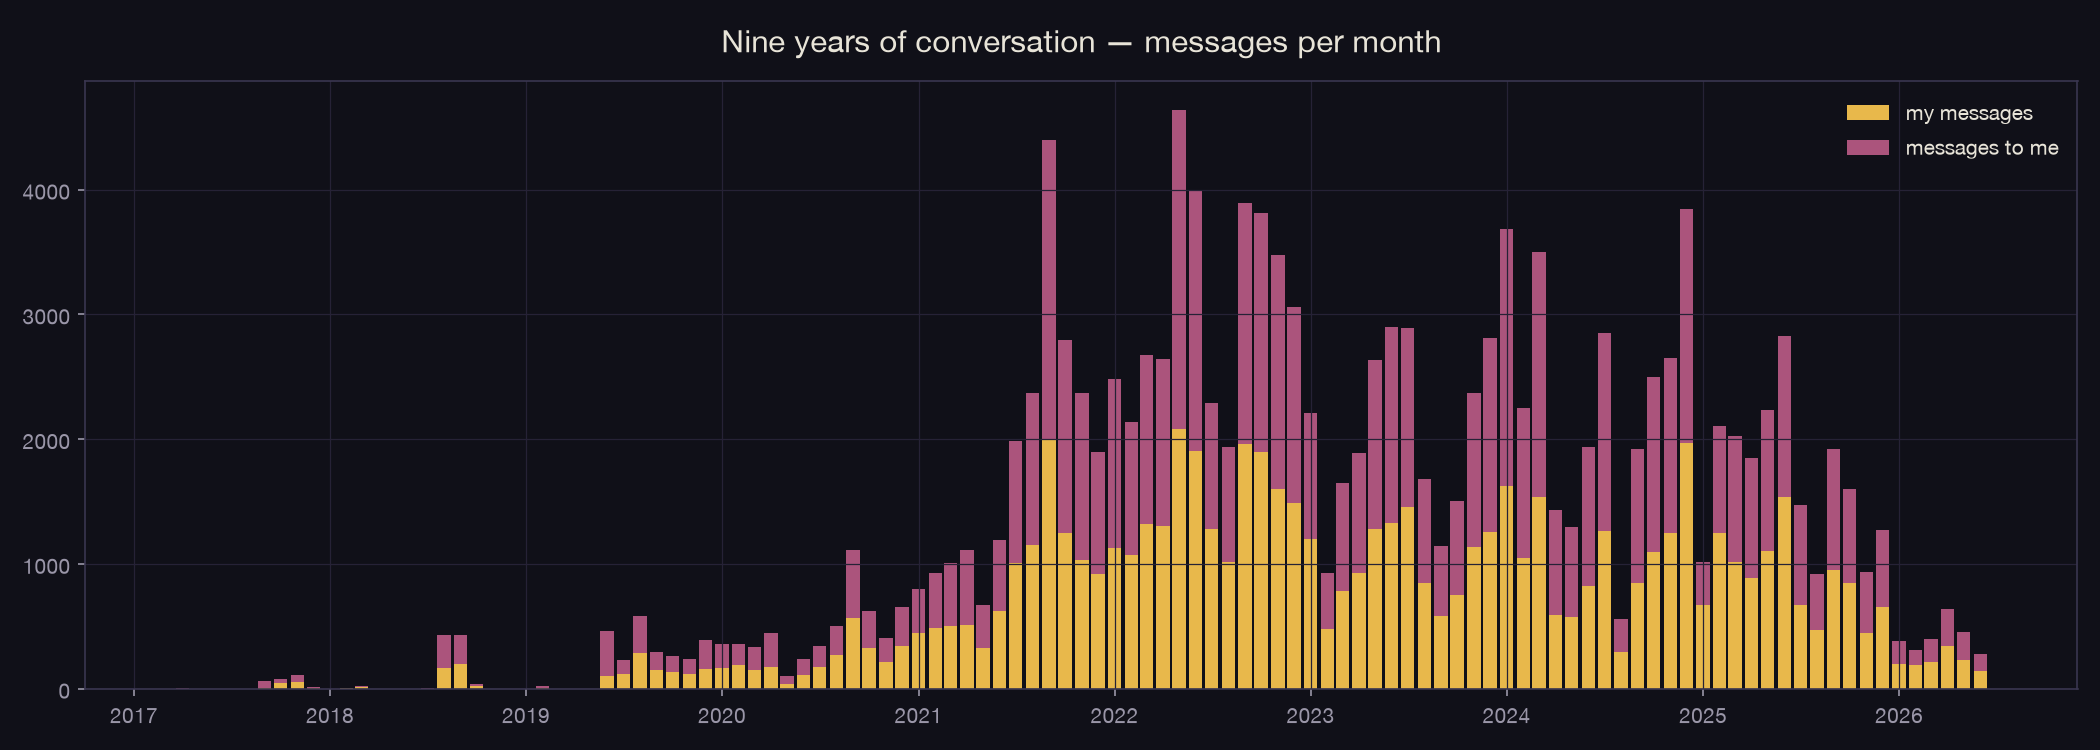

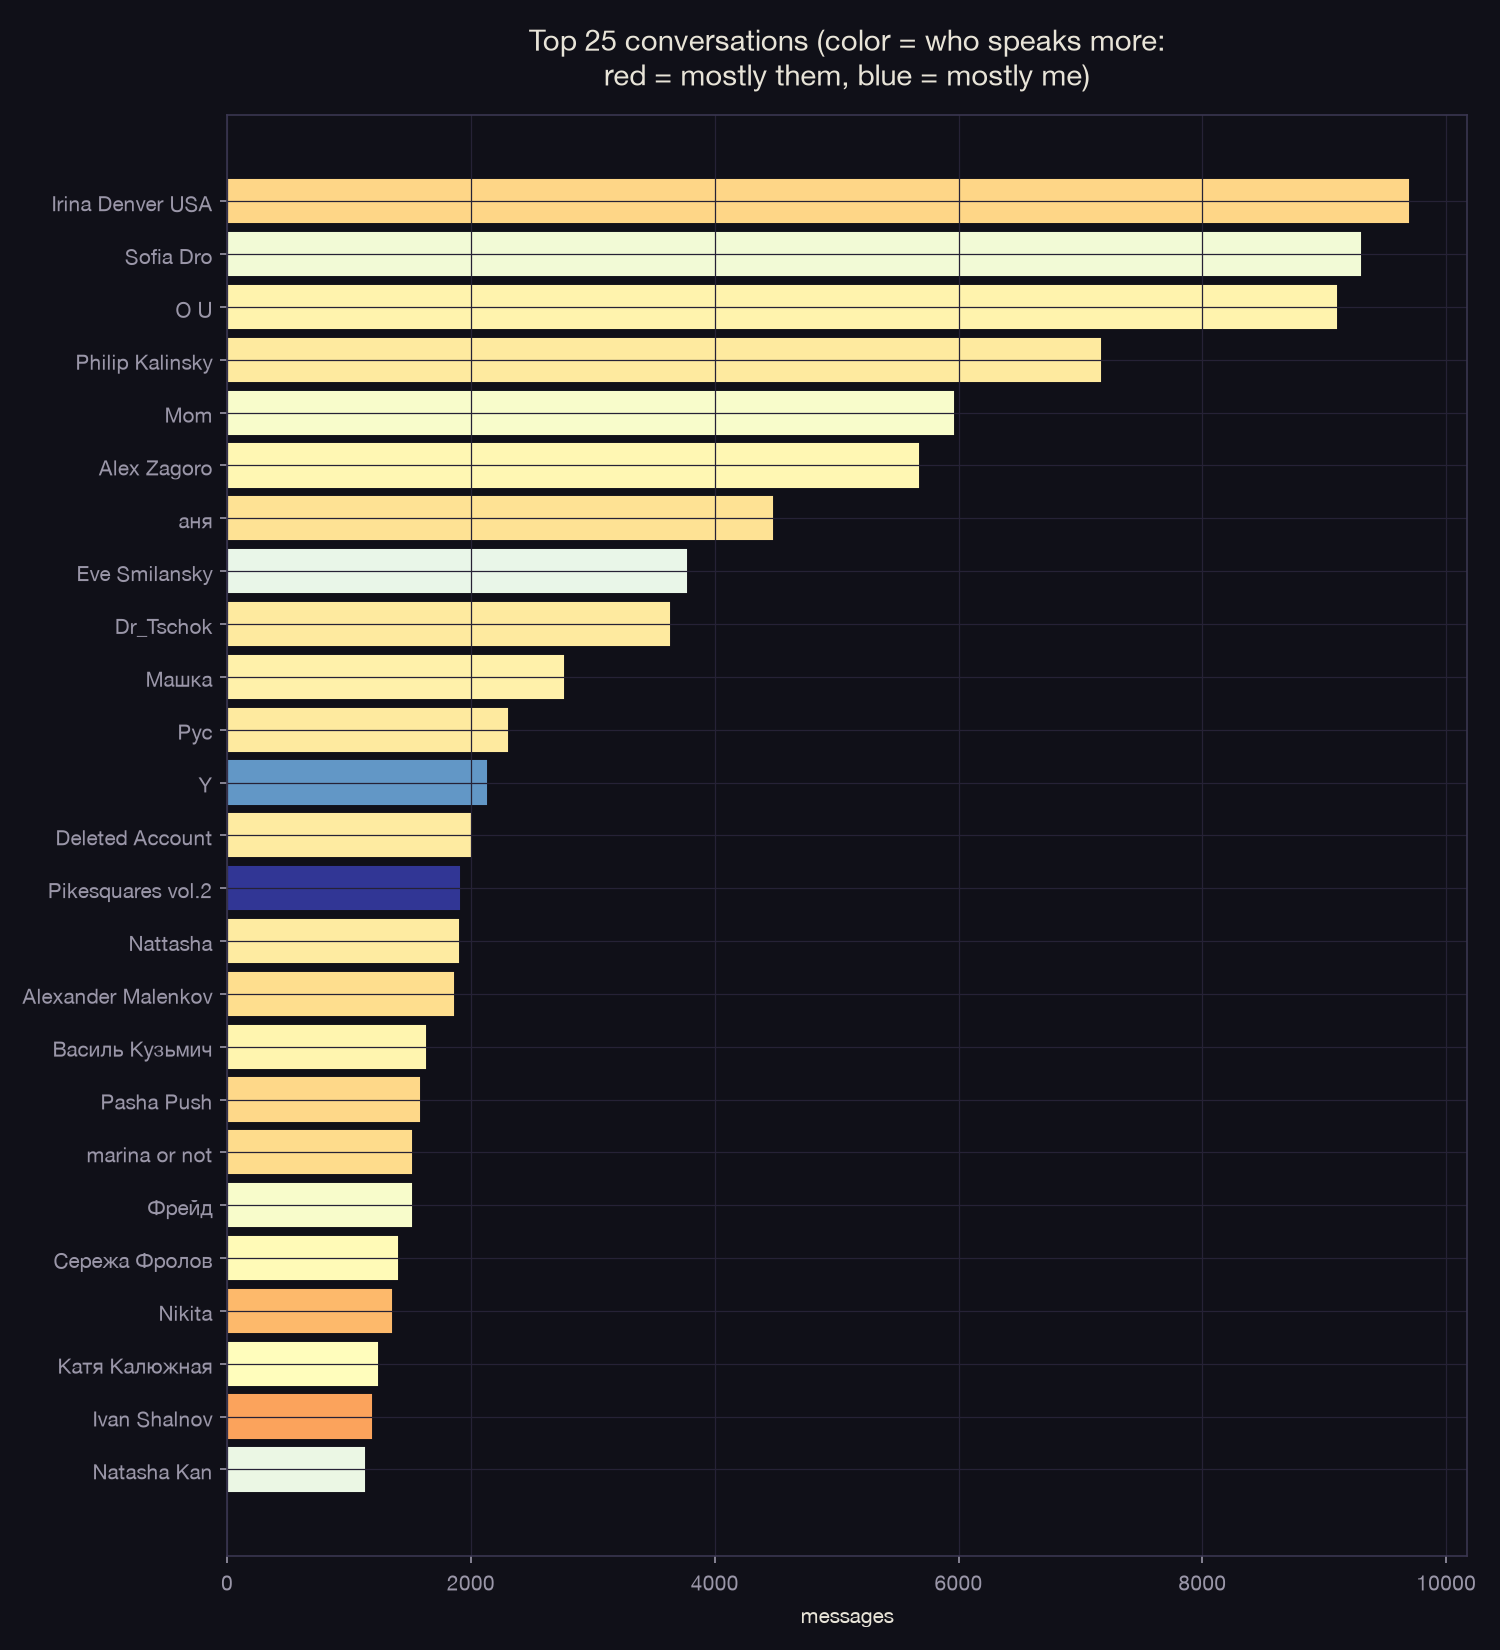

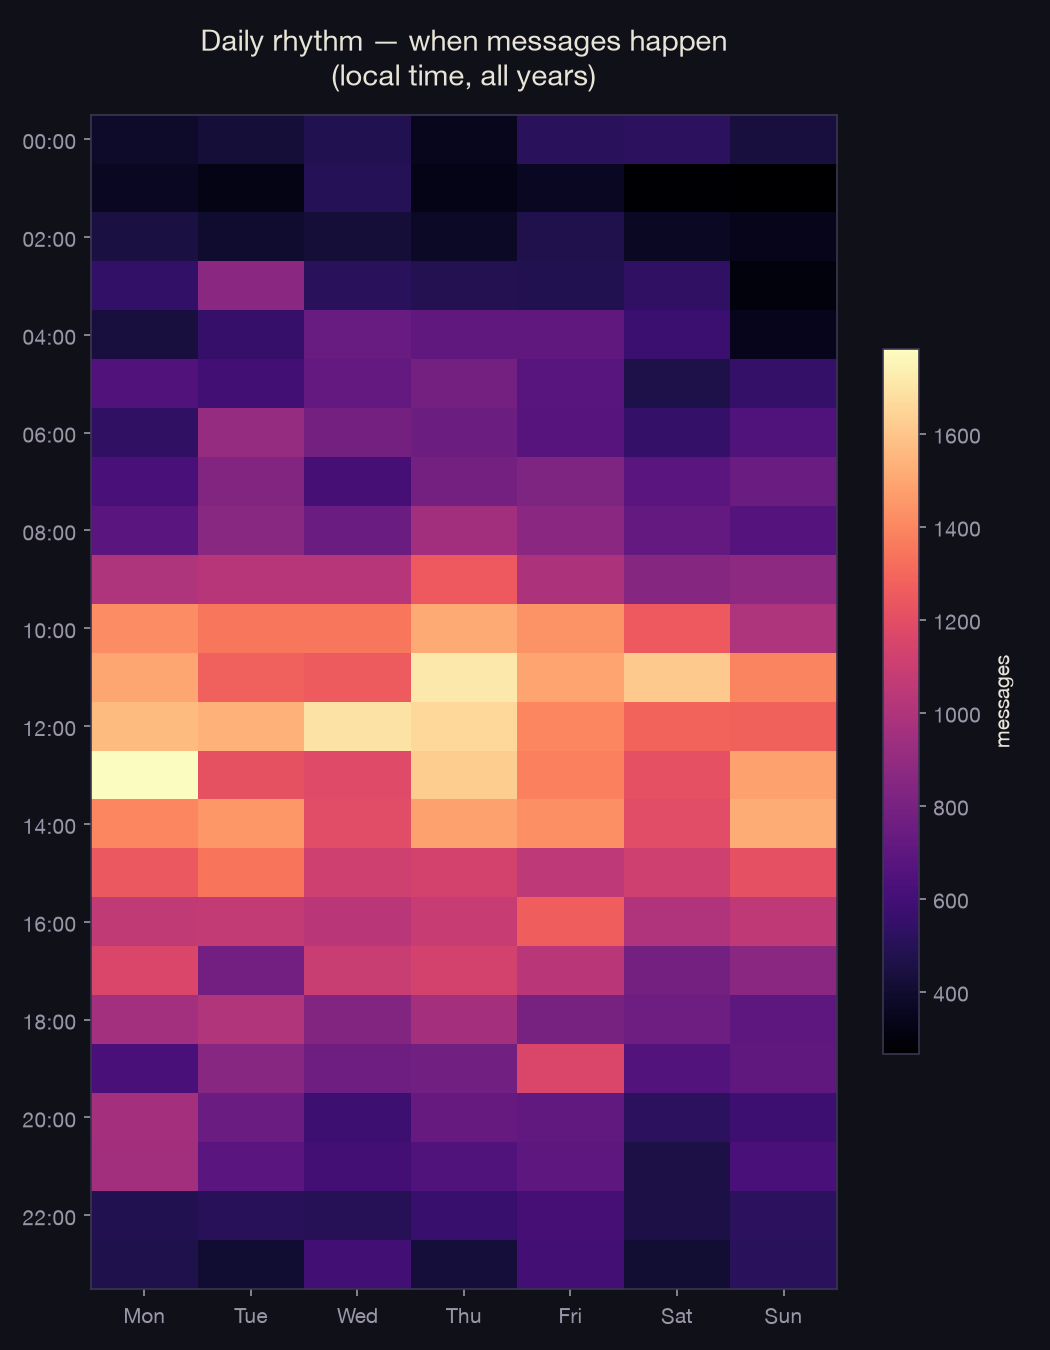

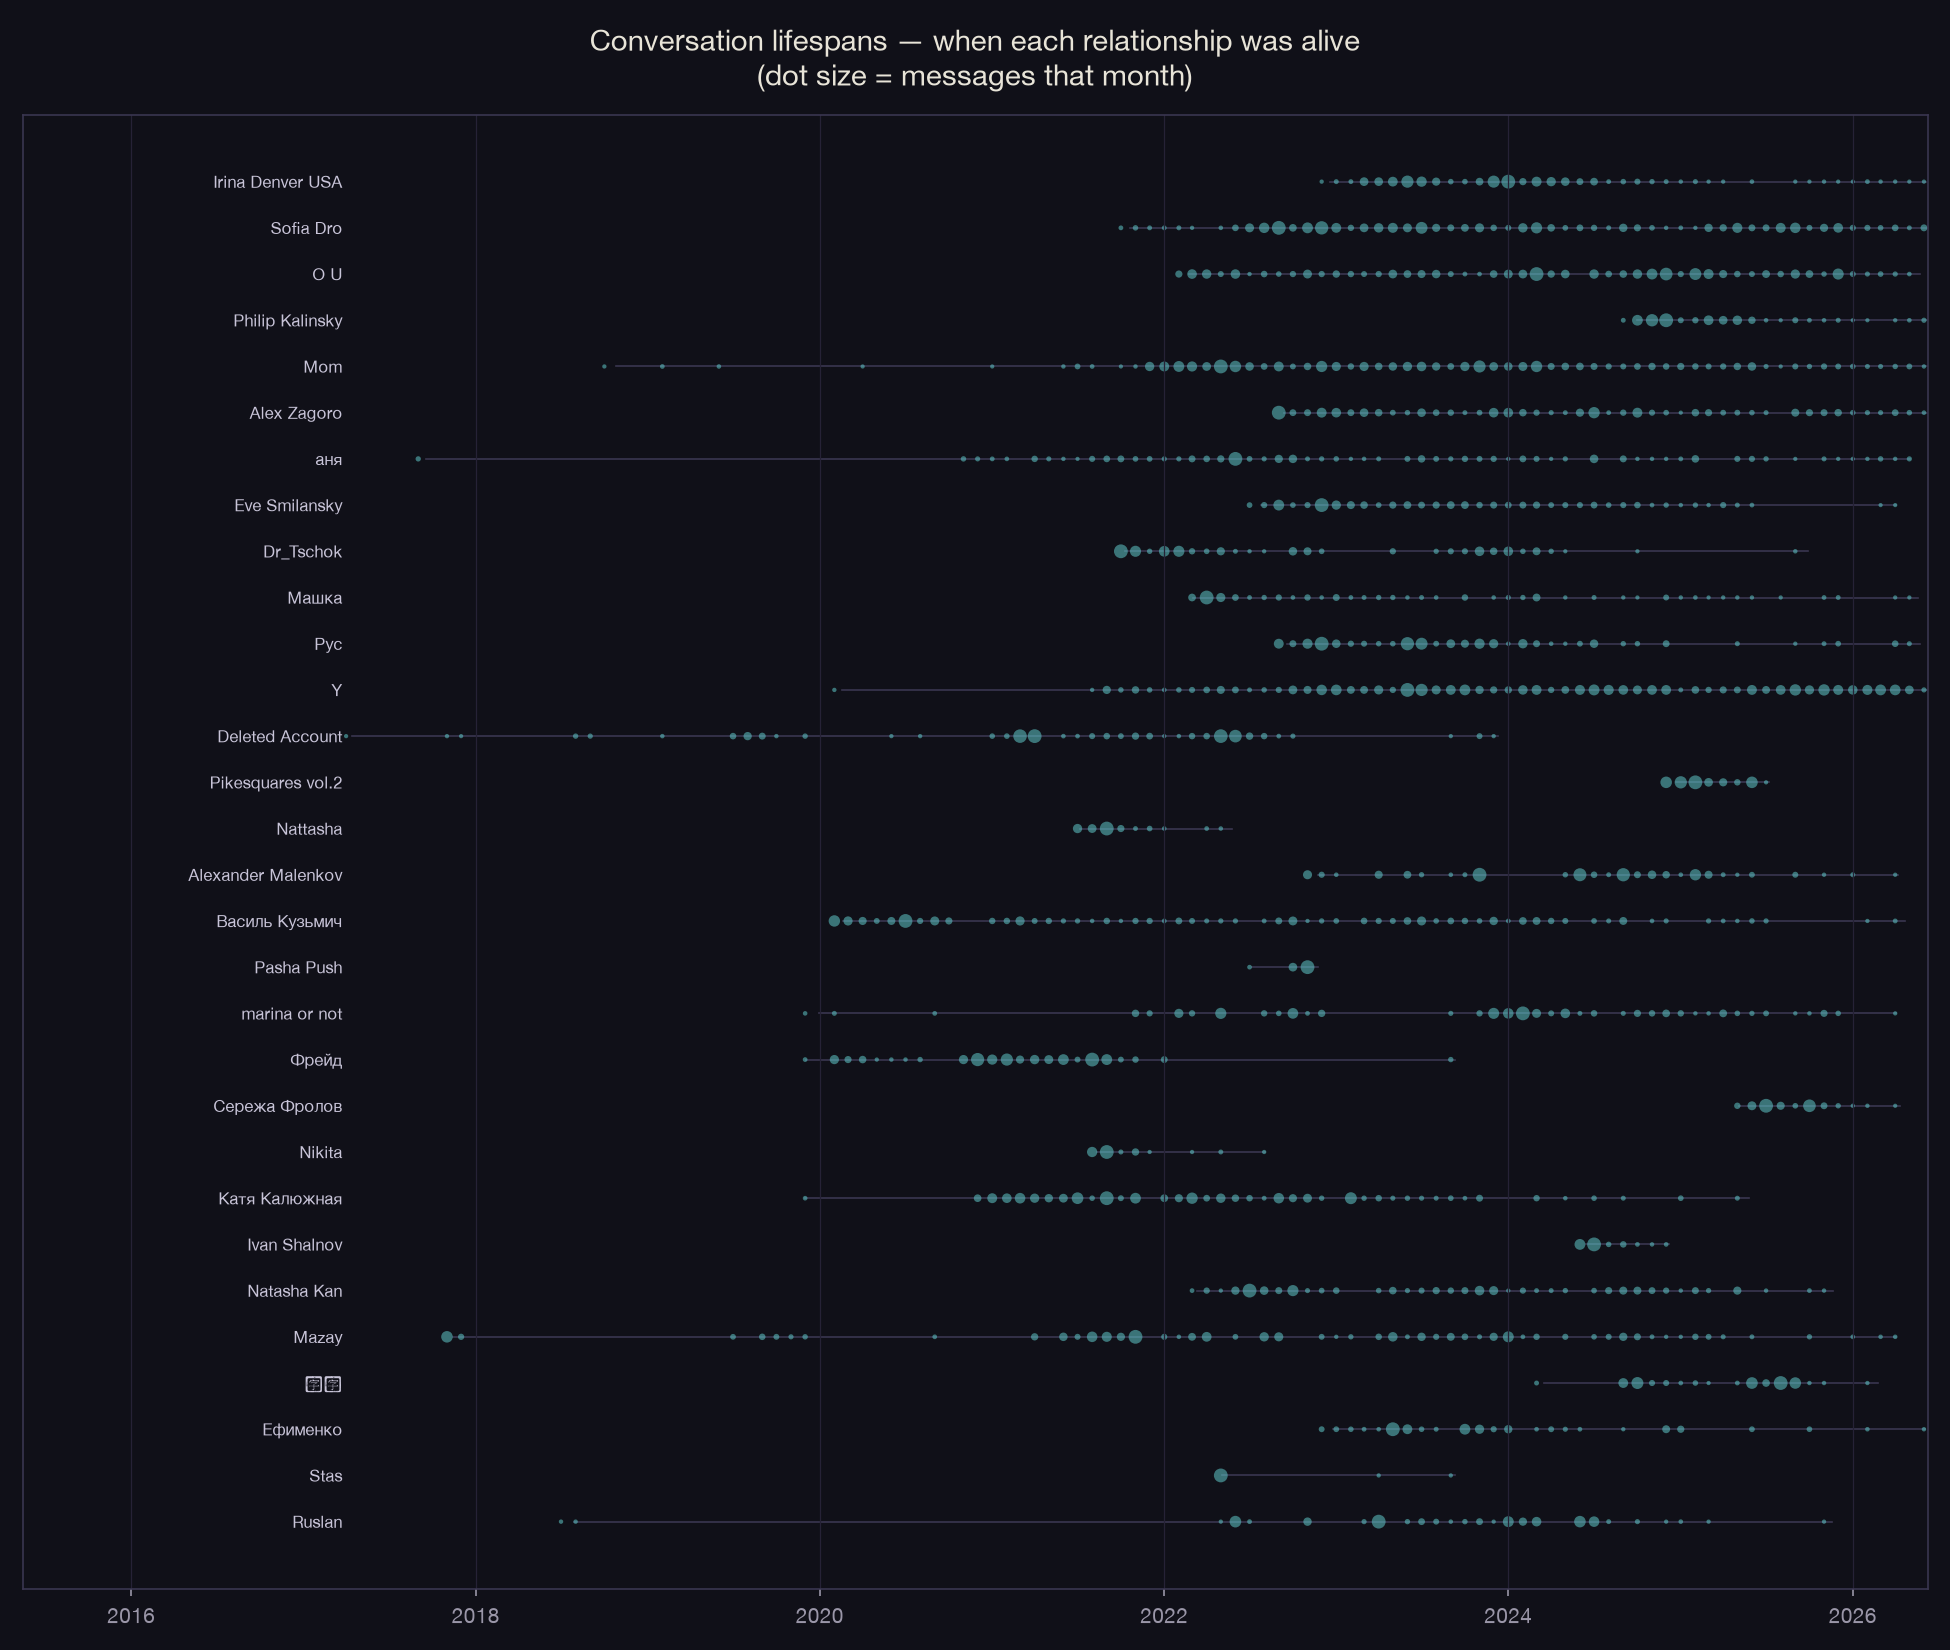

In [2]:
# The four canonical charts, inline
ta.chart_volume(df)
ta.chart_top_chats(df)
ta.chart_rhythm(df)
ta.chart_lifespans(df)

from IPython.display import Image, display
for name in ["telegram_volume_monthly", "telegram_top_chats",
             "telegram_daily_rhythm", "telegram_lifespans"]:
    display(Image(filename=config.VISUALIZATIONS / f"{name}.png", width=900))

In [5]:
# Who did I chat with in a given month? Change the two dates below.
import duckdb
import config

con = duckdb.connect()
con.sql(f"CREATE OR REPLACE VIEW msgs AS SELECT * FROM '{config.TELEGRAM_PARQUET}'")

MONTH_START = '2024-12-01'
MONTH_END   = '2025-01-01'

con.sql(f"""
    SELECT chat_name,
           count(*) AS messages,
           sum(CASE WHEN is_me THEN 1 ELSE 0 END) AS mine
    FROM msgs
    WHERE ts_local >= '{MONTH_START}' AND ts_local < '{MONTH_END}'
    GROUP BY 1
    ORDER BY messages DESC
""").df()

,chat_name,messages,mine
0,Philip Kalinsky,1648,704.0
1,O U,569,296.0
2,Pikesquares vol.2,328,328.0
3,Emir K,159,61.0
4,Diana,82,43.0
5,Машка,82,32.0
6,Alexander Malenkov,67,22.0
7,Ефименко,66,37.0
8,Mom,57,33.0
9,Alex Zagoro,53,31.0


In [16]:
# Zoom into one relationship — change the name on the next line only
PERSON = "Питрович"   # ← change this to any chat_name from your archive

sub = df[df.chat_name == PERSON]
monthly = sub.groupby(["month", "is_me"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 4))
monthly.plot(kind="bar", stacked=True, ax=ax, color=["#e06c9f", "#e8b84b"], width=1.0)
ax.set_xticks(ax.get_xticks()[::6])
ax.set_xticklabels([pd.Timestamp(t.get_text()).strftime("%Y-%m") for t in ax.get_xticklabels()],
                   rotation=45)
ax.legend(["them", "me"], frameon=False)
ax.set_title(f"{PERSON} — the shape of one relationship")
plt.tight_layout()

# the vocabulary of this relationship (words used inside this chat only)
from analysis.word_histograms import tokens
from collections import Counter
vocab = Counter(w for t in sub.text if t for w in tokens(t))
print(f"\n{PERSON}: {len(sub):,} messages, "
      f"{sub.ts_local.min():%Y-%m} .. {sub.ts_local.max():%Y-%m}")
print("vocabulary:", ", ".join(w for w, _ in vocab.most_common(25)))


Питрович: 251 messages, 2022-03 .. 2024-01
vocabulary: грузия, дом, тбилиси, возможность, день, жизнь, страна, армения, жить, момент, сегодня, хороший, машина, красиво, месяц, план, вариант, семья, время, работать, найти, должный, думать, далёкий, тачка


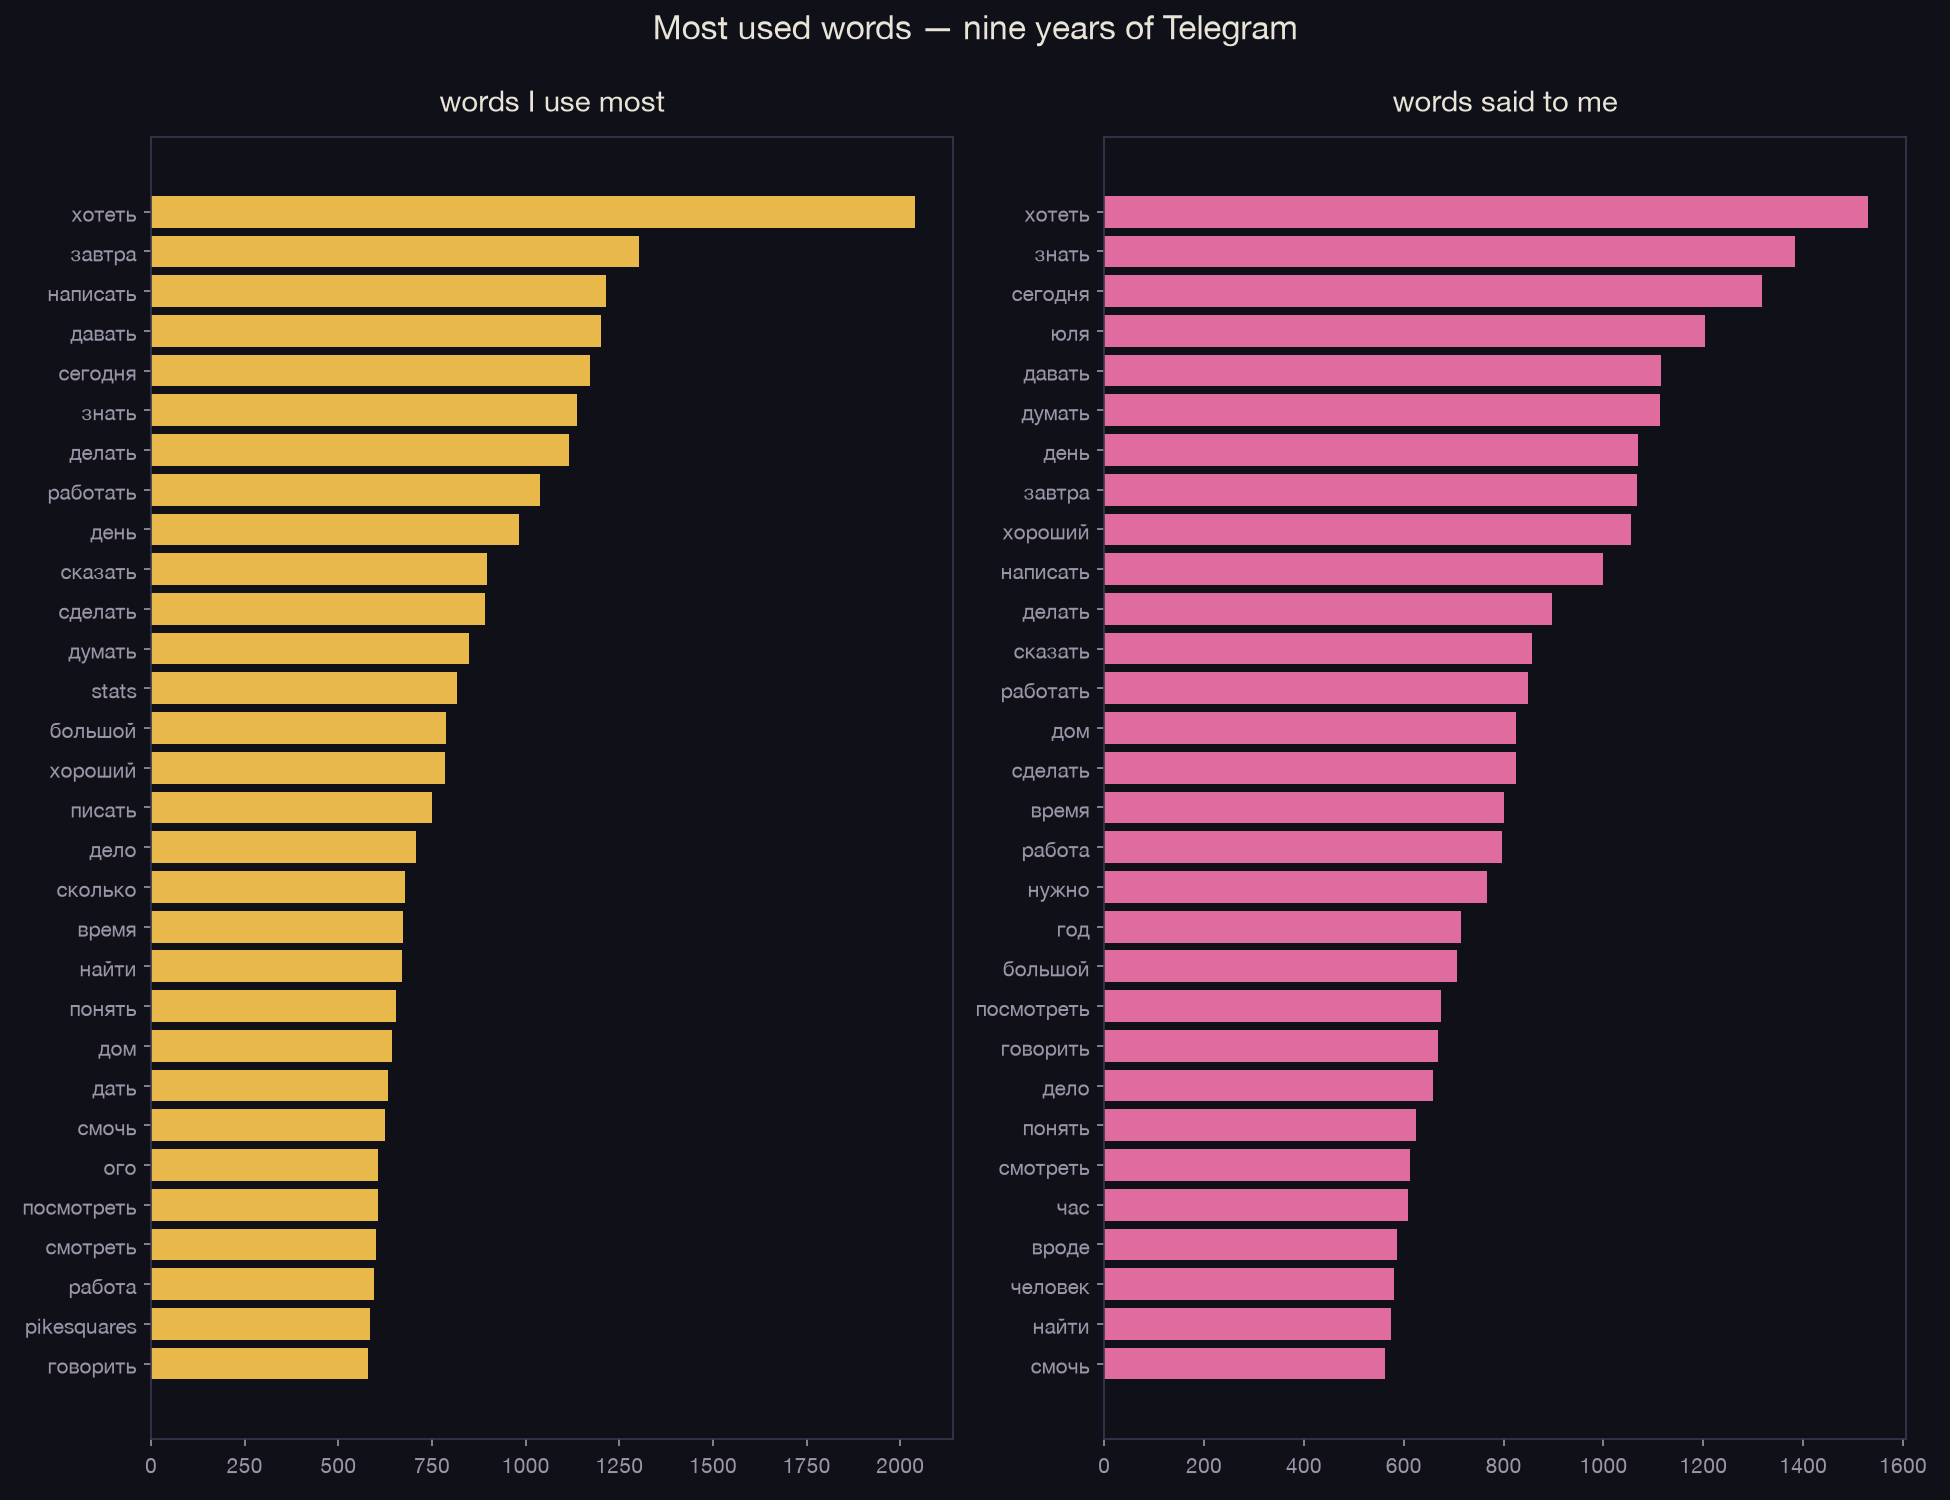

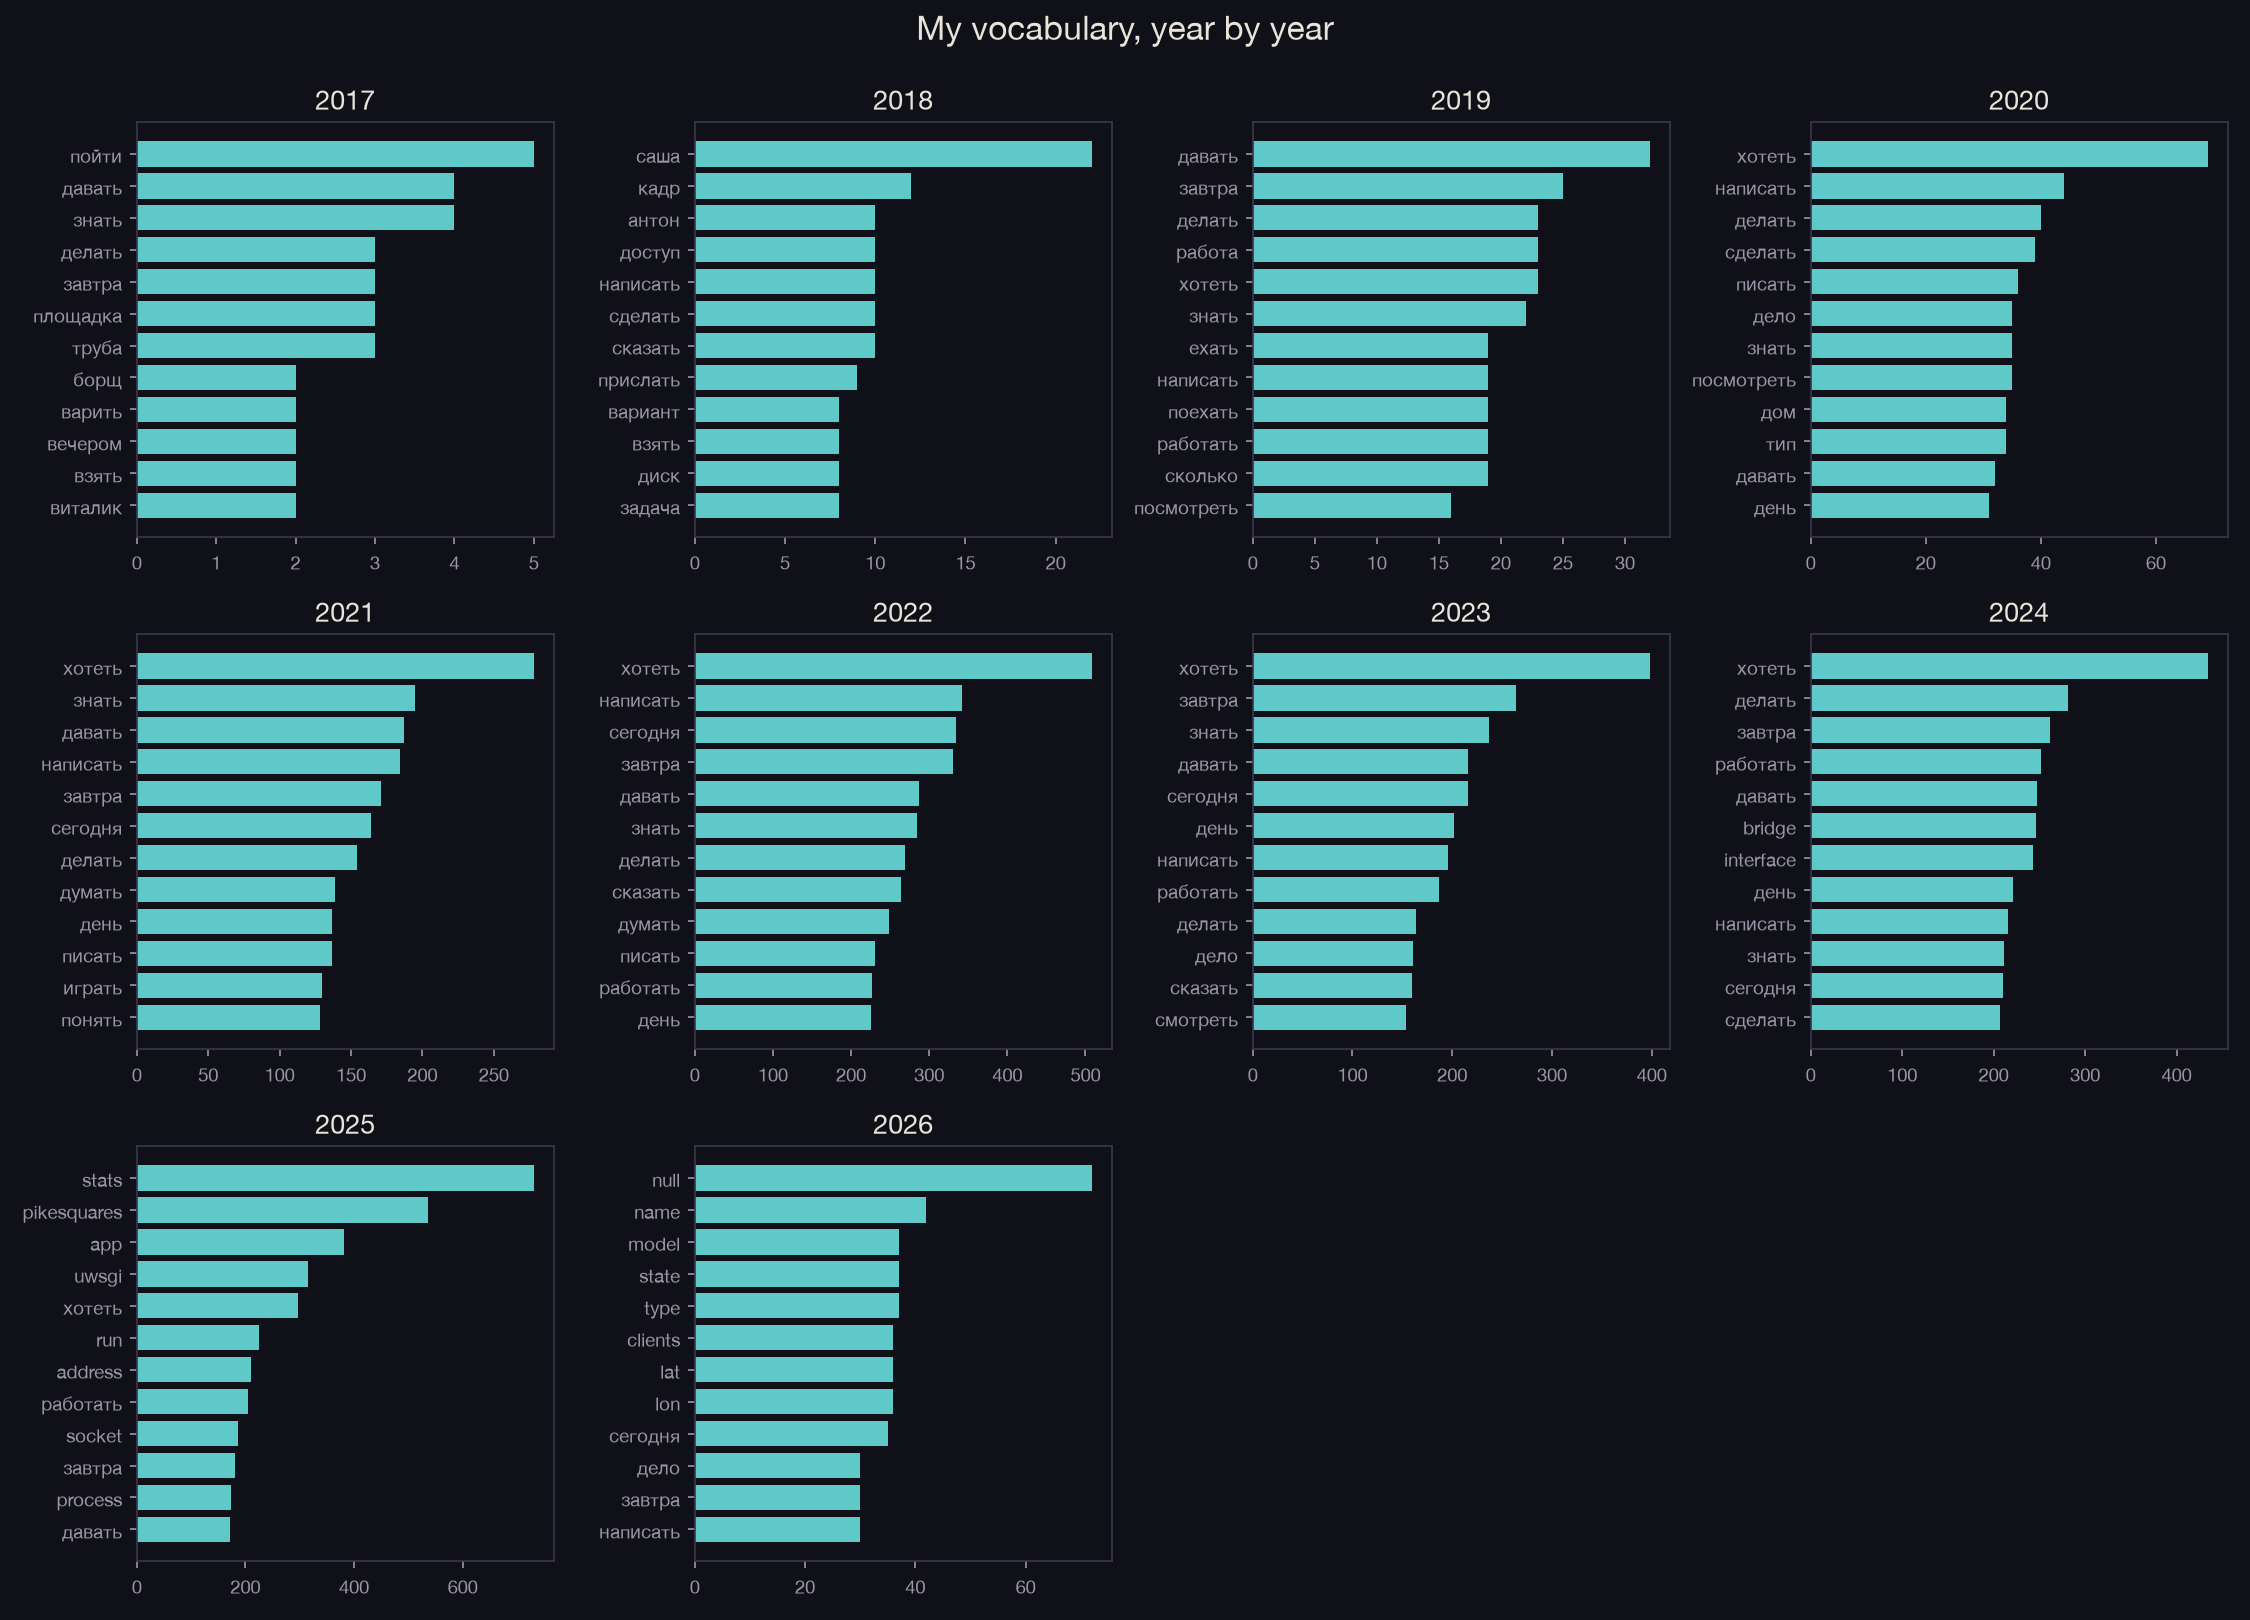

In [5]:
# Word histograms: my words vs words said to me, and my vocabulary by year
from IPython.display import Image, display
display(Image(filename=config.VISUALIZATIONS / "telegram_words_me_vs_them.png", width=900))
display(Image(filename=config.VISUALIZATIONS / "telegram_words_by_year.png", width=900))

# or query the frequency table directly, e.g. trace one word through time:
WORD = "работать"
trace = (freq[freq.lemma == WORD].groupby(["year", "is_me"])["count"].sum()
         .unstack(fill_value=0))
trace.plot(kind="bar", color=["#e06c9f", "#e8b84b"], figsize=(9, 3),
           title=f"'{WORD}' over the years (pink = them, gold = me)")
plt.tight_layout()